# Internship Project — Sales Forecasting by Product Category

## Context
The objective of this internship project is to forecast the quantity of products sold by category over a future prediction horizon of X days, while making the prediction Y days in advance.

### Step 1: Setup

All cleaning and aggregation logic lives in `src/data.py`. This notebook
imports it rather than redefining it, so there is a single implementation
shared with every other notebook — an earlier version of this project kept
separate copies, which silently drifted apart.

Run from the repository root.

In [3]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.data import build_daily_dataset

print("working directory:", os.getcwd())
print("raw data:", config.RAW_EXCEL.exists())

working directory: C:\Users\user\internship
raw data: True


### Step 1: Load the raw data

We use the UCI **Online Retail** dataset, which contains all transactions
from a UK-based online gift retailer between *December 2010* and *December
2011* (541,909 rows). Each row is one product line within one invoice,
with the product description, quantity sold, unit price, invoice date,
customer ID, and country.

### Step 2: Load the category mapping

Individual product descriptions (e.g. "WHITE HANGING HEART T-LIGHT
HOLDER") are too granular to forecast one by one — there are over 4,000
distinct products. We use a category mapping (provided for this
internship) that groups similar products into ~55 broader categories
(e.g. "Tealight Holders & Sets"), which gives us series with enough
volume and regularity to model.

### Step 3: Clean the data

Before aggregating, we remove rows that don't represent real sales:
- Cancelled orders (invoice numbers starting with "C") — these are
  returns, not sales.
- Administrative line items such as postage, discounts, and bank
  charges, which aren't products.
- Rows with zero or negative quantity/price.

**Cancellation handling.** Invoices beginning with `"C"` carry a negative
quantity that reverses an earlier order. Dropping only the negative line —
the obvious approach, and the one used in the first version of this
notebook — leaves the original counted as a real sale.

Two cases dominate this dataset: 74,215 units on 2011-01-18 and 80,995 on
2011-12-09, each cancelled within 30 minutes by the same customer for the
same product. Left in, the second gave Children's Toys & Playsets a test R²
of −2211, because the spike sits in training and inflates every lag and
rolling feature around it.

`src/data.py` matches each cancellation to its originating order on customer,
product and exactly opposite quantity, and removes both sides.

### Step 4: Map products to categories

Each cleaned transaction's product description is matched (case-
insensitive) against the category mapping from Step 2, so every row is
tagged with its category. Descriptions with no match (a small fraction,
mostly non-product noise) are labeled "Unclassified".

### Step 5: Aggregate to daily category-level sales

We sum quantities by day and category to get one time series per
category. Days with no recorded sales for a given category are
explicitly filled in as zero — this matters because gaps would
otherwise be invisible to a forecasting model and bias it.

### Running the full preparation

`build_daily_dataset()` performs every step described above and writes
`data/processed/daily_category_sales_clean.csv`. The printed output reports
how many cancellations were matched, the maximum daily quantity after
cleaning, and the shape of the resulting date × category grid.

In [10]:
daily = build_daily_dataset()
daily.head()

reading C:\Users\user\internship\data\raw\Online Retail.xlsx
raw rows: 541909
  cancellation rows           : 9288
  matched to an original order: 2899 (31%)
  rows removed in total       : 12187
  max quantity after          : 12540
rows after cleaning: 524957 (96.9% kept)
unclassified rows: 0.15%
categories: 55
daily rows: 20570 (374 days x 55 categories)
written to C:\Users\user\internship\data\processed\daily_category_sales_clean.csv


,Date,Category,Quantity,Revenue,Orders
0,2010-12-01,"Bag Charms, Key Rings & Phone Charms",1,1.66,1
1,2010-12-02,"Bag Charms, Key Rings & Phone Charms",206,133.90,3
2,2010-12-03,"Bag Charms, Key Rings & Phone Charms",1,1.25,1
3,2010-12-04,"Bag Charms, Key Rings & Phone Charms",0,0.00,0
4,2010-12-05,"Bag Charms, Key Rings & Phone Charms",58,37.90,8


In [11]:
# The full grid matters: a category with no sales on a given day must appear
# as zero, not be absent. Otherwise lag_7 stops meaning "one week ago" and
# every downstream feature is quietly wrong. build_daily_dataset asserts the
# date index is contiguous.
print("days      :", daily["Date"].nunique())
print("categories:", daily["Category"].nunique())
print("rows      :", len(daily))
print("zero days :", (daily["Quantity"] == 0).sum())
print("max daily quantity:", daily["Quantity"].max())

days      : 374
categories: 55
rows      : 20570
zero days : 4573
max daily quantity: 8855


### Step 6: Exploratory data analysis

Before modeling, we visualize the daily sales to spot trend, seasonality,
and any irregularities that should inform model choice.

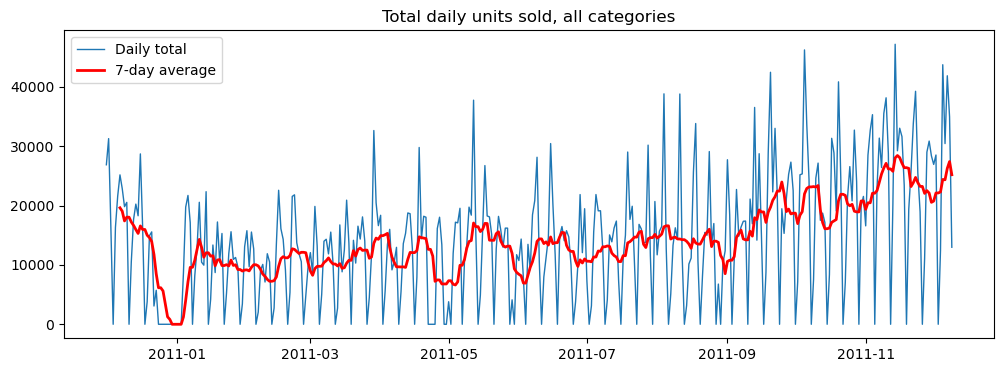

weekday
Monday       16232.415094
Tuesday      19295.735849
Wednesday    18844.611111
Thursday     22058.111111
Friday       14735.444444
Saturday         0.000000
Sunday        8753.830189
Name: Quantity, dtype: float64


In [13]:
import matplotlib.pyplot as plt

overall = daily.groupby("Date")["Quantity"].sum()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(overall.index, overall.values, lw=1, label="Daily total")
ax.plot(overall.index, overall.rolling(7).mean(), lw=2, color="red", label="7-day average")
ax.set_title("Total daily units sold, all categories")
ax.legend()
plt.show()

# Average sales by day of week
overall_df = overall.reset_index()
overall_df["weekday"] = overall_df["Date"].dt.day_name()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_avg = overall_df.groupby("weekday")["Quantity"].mean().reindex(order)
print(weekday_avg)

### Step 7: Stationarity Test
For the stationarity test and ACF/PACF analysis, I focus on one representative category: **Tealight Holders & Sets**.

This allows an initial analysis of the time series behavior before generalizing the same approach to other product categories.

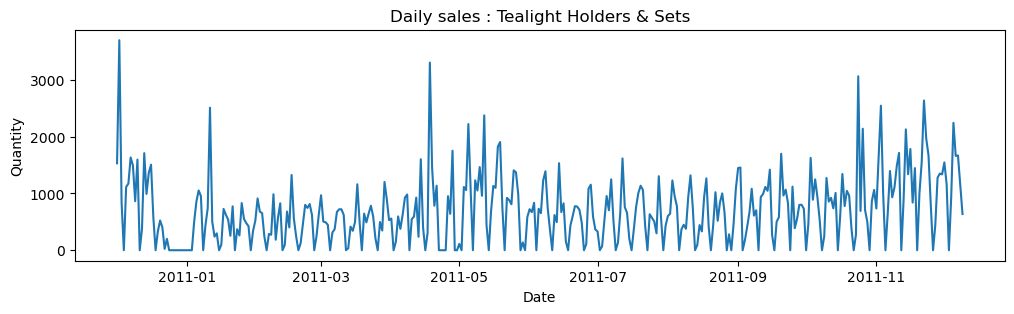

In [15]:
from statsmodels.tsa.stattools import adfuller
#From the daily dataframe, keep only Tealight Holders & Sets rows, set Date as the index, grab only the Quantity column, and sort by date
ts=daily[daily["Category"]=="Tealight Holders & Sets"].set_index("Date")["Quantity"].sort_index()

fig,ax=plt.subplots(figsize=(12,3))
ax.plot(ts)
ax.set_title("Daily sales : Tealight Holders & Sets")
ax.set_xlabel("Date")
ax.set_ylabel("Quantity")
plt.show()

#### Observations — Tealight Holders & Sets

- **Sales evolution:** sales fluctuate throughout the year, with higher activity visible from September to the Christmas period.
- **Weekly pattern:** repeated drops and spikes suggest a possible weekly pattern. Saturday sales are equal to zero in the dataset, which may reflect a business or data collection pattern.
- **Holiday / calendar effect:** sales drop sharply around early January, possibly due to holiday-related business activity.
- **Large spikes:** some exceptional peaks may correspond to bulk orders or unusual demand events.

#### Implications for modeling

- The time series contains short-term fluctuations and possible weekly effects.
- Lag features such as `lag_1`, `lag_7`, `lag_14`, and `lag_28` may be useful.
- Rolling-window features can help capture recent sales behavior.
- Statistical models such as ARMA and SARIMA can be tested, especially to compare non-seasonal and weekly seasonal structures.

In [17]:
# ADF test
result = adfuller(ts)
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
if result[1] < 0.05:
    print("Stationary (p < 0.05)")
else:
    print("Not stationary (p >= 0.05)")

ADF Statistic: -3.0501
p-value: 0.0305
Stationary (p < 0.05)


##### Conclusion: 
The **ADF** test rejects the unit-root hypothesis for this selected category. However, the plot still shows visible weekly effects and seasonal changes in sales intensity. Therefore, both non-seasonal and seasonal models can be tested and compared empirically.

### Step 8: ACF and PACF Plots
ACF shows correlation between today's sales and past values.
PACF shows the direct correlation removing indirect effects.
Together they help choose the right lag features and SARIMA orders.

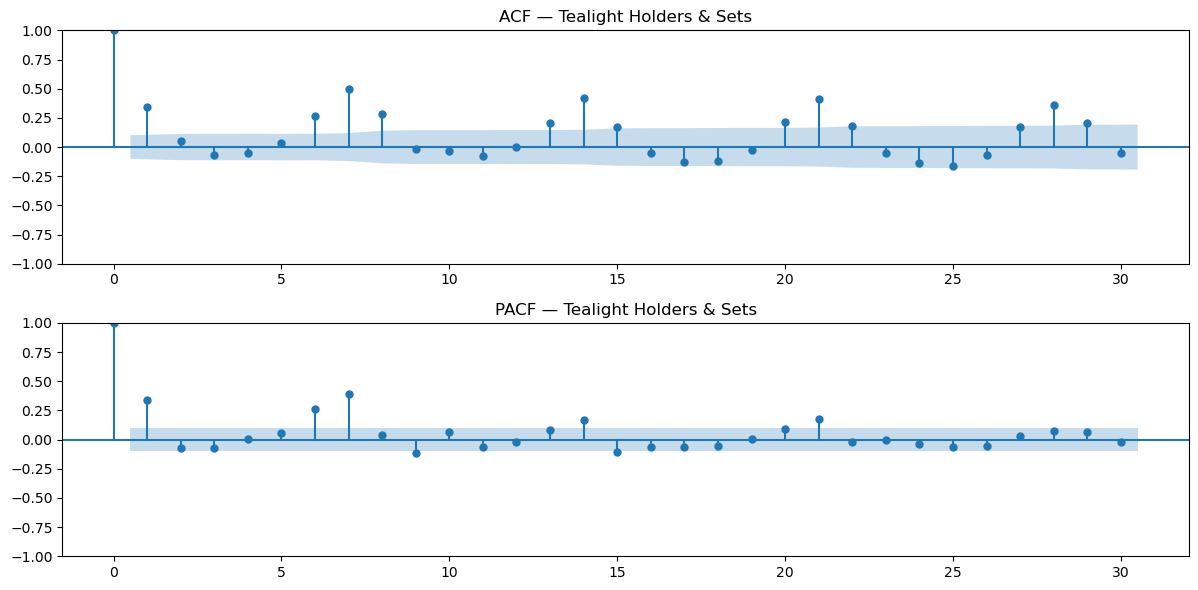

In [20]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

plot_acf(ts, lags=30, ax=ax1)
ax1.set_title("ACF — Tealight Holders & Sets")

plot_pacf(ts, lags=30, ax=ax2)
ax2.set_title("PACF — Tealight Holders & Sets")

plt.tight_layout()
plt.show()

#### Interpretation of ACF and PACF

The ACF and PACF plots for **Tealight Holders & Sets** show significant autocorrelation at short lags, especially at **lag 1**. This means that recent sales values contain useful information for predicting future sales.

Several significant spikes also appear around weekly-related lags, especially around **lag 7, lag 14, lag 21, and lag 28**. This suggests the presence of a possible weekly pattern in the sales series.

The ACF does not cut off sharply after the first lag, which means the series may contain both short-term dependency and seasonal effects. The PACF also shows some significant lags, especially around lag 1 and weekly lags.

#### Modeling implications

- Lag features such as `lag_1`, `lag_7`, `lag_14`, `lag_21`, and `lag_28` may be useful.
- Rolling-window features can help capture recent sales behavior.
- Since the ADF test suggests stationarity, ARMA models with `d = 0` can be tested as a first statistical benchmark.
- Because weekly effects are visible, SARIMA with seasonal period `s = 7` should also be tested and compared.
- Final model choice should be based on validation metrics, not only on ACF/PACF visual inspection.

### Next steps

The dataset is now ready for modelling. The remaining work is split across
dedicated notebooks rather than continued here:

- **`03_split_strategy.ipynb`** — comparison of four train/test split
  strategies, and the stratified block split that reduced result variance
  5–12×.
- **`02_modeling.ipynb`** — single-category analysis, feature engineering
  and model comparison.
- **`pipeline.ipynb`** — the reusable pipeline applied across all 54
  categories.
- **`04_tabfm.ipynb`** — evaluation of a zero-shot tabular foundation model.

An earlier version of this notebook continued with a first modelling
attempt: pooled categories, a chronological 80/20 split, and a comparison of
two baselines against Linear Regression and Random Forest. That experiment
has been removed because its split strategy is superseded by the analysis in
`03_split_strategy.ipynb`, and keeping it here duplicated feature
engineering that now lives in `src/features.py`.

Headline findings from the full study are summarised in `README.md`, with
detail in `RESULTS_REVISED.md` and `RESULTS_54_AND_TABFM.md`.